### Project Title: Loan Approval Prediction & RAG Insights System
Prepared By:

- Name: Abhishek Sahu
- Domain: Data Science
- ID : CT_CSI_DS_5981

Objective -
To develop a robust machine learning pipeline and an intelligent RAG-based chatbot that predicts loan approval and provides insights by analyzing applicant data. The solution also includes interactive visualizations and memory-based Q&A on dataset trends.

📁 Project Components
1. Data Preprocessing & Analysis
Dataset Source: Kaggle - Loan Approval Prediction

Steps Performed:

- Handled missing values (mean/mode imputation).
- Detected and removed outliers using IQR method.
- Encoded categorical variables using LabelEncoder.
- Scaled numeric features using StandardScaler.
- Visualized key distributions and correlations using Plotly and Matplotlib.

2. Model Building

Algorithms Used:

- Logistic Regression
- Decision Tree
- Random Forest
- Naive Bayes
- K-Nearest Neighbors
- Support Vector Machine

3. 🧠 RAG-based Q&A Chatbot

- Technology: FAISS + SentenceTransformer + Flan-T5 (via Hugging Face)

Functionality:

- Retrieves most relevant insights from pre-generated loan data reports.
-Answers questions like "Which factors affect loan approval most?"
- Maintains memory (chat history) for context-aware conversation.
- Visuals Embedded: Uses Streamlit to render charts alongside text answers.

4. 📈 Visualization Dashboard

Tools: Matplotlib, Plotly, Seaborn, Streamlit

5. 🧪 Test Set Evaluation

- Applied best-performing model on test data
- Produced prediction labels (Y/N) and computed evaluation metrics (accuracy, classification report)

RAG: FAISS + Flan-T5 (Generative QA)

Deployment: Streamlit App

### Loan Approval Dataset Metadata

| Column Name         | Data Type | Example Values                    | Missing Values | Description                                 |
| ------------------- | --------- | --------------------------------- | -------------- | ------------------------------------------- |
| `Loan_ID`           | object    | LP001002, LP001003                | ❌ No           | Unique identifier for each loan application |
| `Gender`            | object    | Male, Female                      | ✅ Yes          | Applicant’s gender                          |
| `Married`           | object    | Yes, No                           | ✅ Yes          | Marital status of applicant                 |
| `Dependents`        | object    | 0, 1, 2, 3+                       | ✅ Yes          | Number of dependents                        |
| `Education`         | object    | Graduate, Not Graduate            | ❌ No           | Education level of applicant                |
| `Self_Employed`     | object    | Yes, No                           | ✅ Yes          | Self-employment status                      |
| `ApplicantIncome`   | int64     | 1500, 4583, 6000                  | ❌ No           | Monthly income of the applicant             |
| `CoapplicantIncome` | float64   | 0.0, 1508.0                       | ❌ No           | Monthly income of co-applicant              |
| `LoanAmount`        | float64   | 128.0, 66.0, 120.0 (in thousands) | ✅ Yes          | Loan amount requested                       |
| `Loan_Amount_Term`  | float64   | 360.0, 120.0, 180.0               | ✅ Yes          | Loan repayment term in months               |
| `Credit_History`    | float64   | 1.0, 0.0                          | ✅ Yes          | Credit history (1: good, 0: bad)            |
| `Property_Area`     | object    | Urban, Semiurban, Rural           | ❌ No           | Type of property area                       |
| `Loan_Status`       | object    | Y, N                              | ❌ No           | **Target** variable: loan approved or not   |


###  Importing Libraries

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Load the dataset
df = pd.read_csv(r"C:\Users\sahua\OneDrive\Desktop\Data_science\Celebal Technology\Week8_Task\Training Dataset.csv")

### Data profiling

In [23]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [24]:
# showing last 5 rows
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [25]:
# Showing dimensions of the dataset
df.shape

(614, 13)

In [26]:
# showing column names
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [27]:
# checking for data types
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [28]:
df.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

In [29]:
# showing information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [30]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


### Data Cleaning and Preprocessing

In [31]:
# checking for duplicated values
df.duplicated().sum()

0

In [32]:
# checking for missing values
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [35]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())


In [36]:
# checking for missing values
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [39]:
from sklearn.preprocessing import LabelEncoder

# Create a copy to work with
encoded_df = df.copy()

# Initialize encoder
le = LabelEncoder()

# Columns to encode
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education',
                    'Self_Employed', 'Property_Area', 'Loan_Status']

# Apply LabelEncoder
for col in categorical_cols:
    encoded_df[col] = le.fit_transform(encoded_df[col])


In [40]:
from sklearn.preprocessing import StandardScaler

# Columns to scale
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

# Initialize scaler
scaler = StandardScaler()

# Apply scaling
encoded_df[numeric_cols] = scaler.fit_transform(encoded_df[numeric_cols])


In [42]:
encoded_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,0.072991,-0.554487,-0.211241,0.273231,1.0,2,1
1,LP001003,1,1,1,0,0,-0.134412,-0.038732,-0.211241,0.273231,1.0,0,0
2,LP001005,1,1,0,0,1,-0.393747,-0.554487,-0.948996,0.273231,1.0,2,1
3,LP001006,1,1,0,1,0,-0.462062,0.251980,-0.306435,0.273231,1.0,2,1
4,LP001008,1,0,0,0,0,0.097728,-0.554487,-0.056551,0.273231,1.0,2,1


#### Outliers Detection

Before

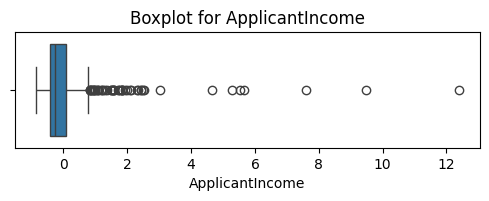

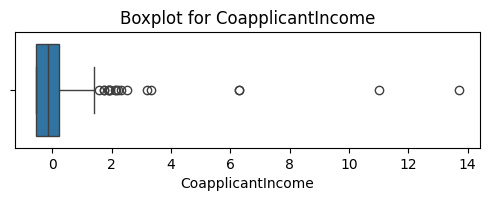

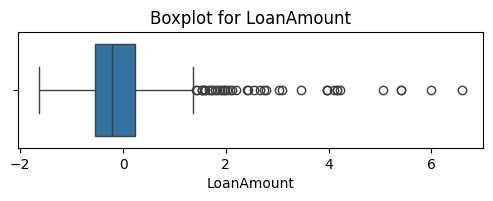

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_cols:
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(data=encoded_df, x=col)
    plt.title(f"Boxplot for {col}")
    plt.show()


In [45]:
def remove_outliers_iqr(df, columns):
    cleaned_df = df.copy()
    for col in columns:
        Q1 = cleaned_df[col].quantile(0.25)
        Q3 = cleaned_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Filter out outliers
        cleaned_df = cleaned_df[(cleaned_df[col] >= lower_bound) & (cleaned_df[col] <= upper_bound)]
    return cleaned_df

numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
df_no_outliers = remove_outliers_iqr(encoded_df, numeric_cols)


After

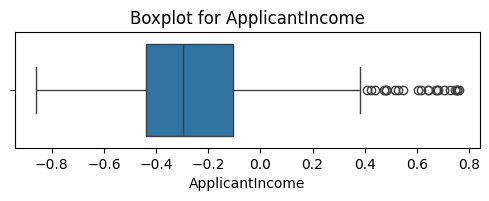

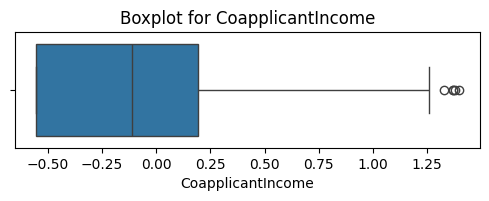

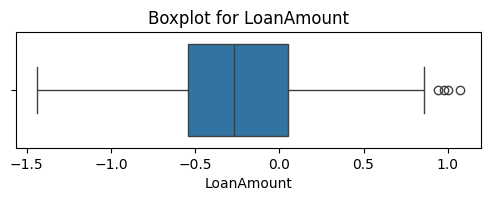

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_cols:
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(data=df_no_outliers, x=col)
    plt.title(f"Boxplot for {col}")
    plt.show()


### Data Visualization

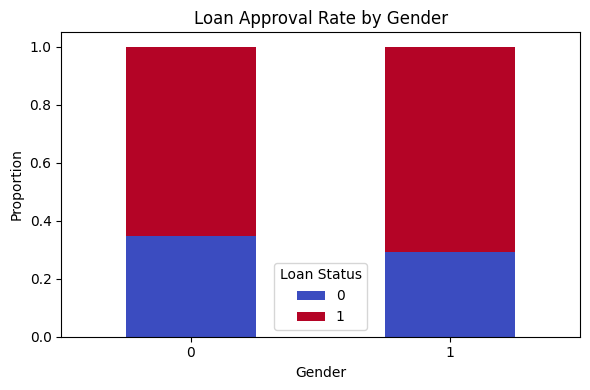

In [50]:
import matplotlib.pyplot as plt

approval_by_gender = df_no_outliers.groupby('Gender')['Loan_Status'].value_counts(normalize=True).unstack()
approval_by_gender.plot(kind='bar', stacked=True, figsize=(6,4), colormap='coolwarm')
plt.title('Loan Approval Rate by Gender')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Loan Status')
plt.tight_layout()
plt.show()


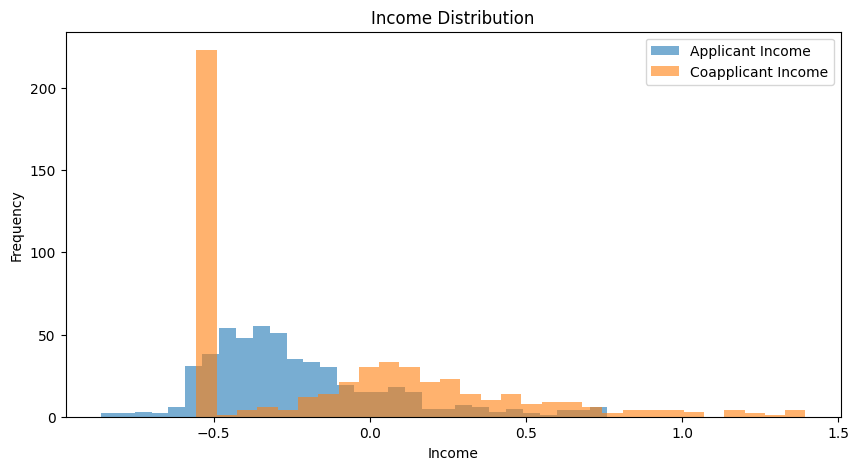

In [51]:
plt.figure(figsize=(10,5))
plt.hist(df_no_outliers['ApplicantIncome'], bins=30, alpha=0.6, label='Applicant Income')
plt.hist(df_no_outliers['CoapplicantIncome'], bins=30, alpha=0.6, label='Coapplicant Income')
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.legend()
plt.show()


<Figure size 600x400 with 0 Axes>

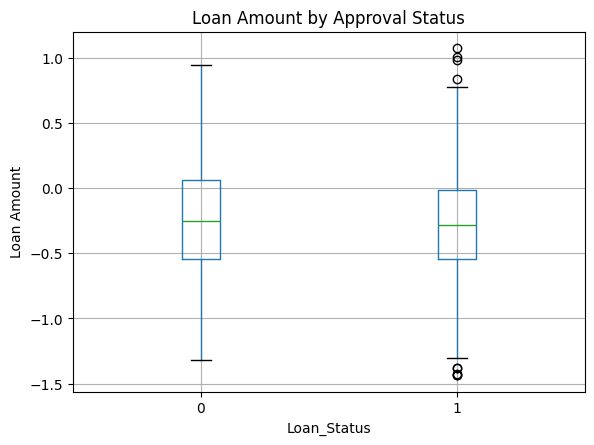

In [53]:
plt.figure(figsize=(6, 4))
df_no_outliers.boxplot(column='LoanAmount', by='Loan_Status')
plt.title('Loan Amount by Approval Status')
plt.suptitle('')
plt.ylabel('Loan Amount')
plt.show()


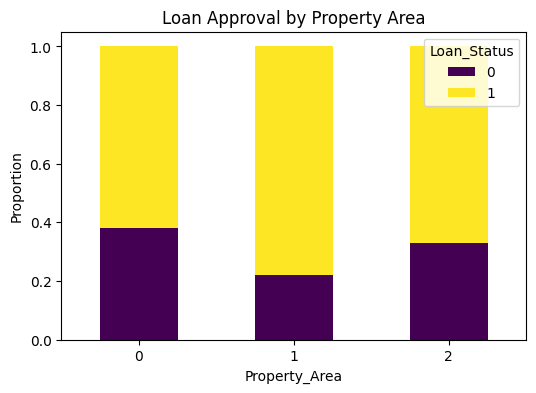

In [54]:
property_approval = df_no_outliers.groupby('Property_Area')['Loan_Status'].value_counts(normalize=True).unstack()
property_approval.plot(kind='bar', stacked=True, figsize=(6,4), colormap='viridis')
plt.title('Loan Approval by Property Area')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.show()


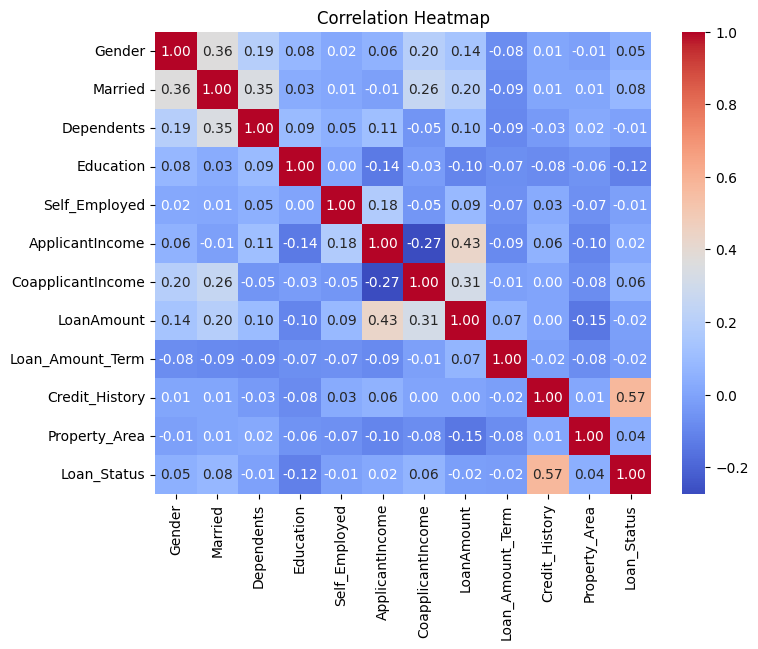

In [55]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(df_no_outliers.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


In [56]:
df_no_outliers.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,0.072991,-0.554487,-0.211241,0.273231,1.0,2,1
1,LP001003,1,1,1,0,0,-0.134412,-0.038732,-0.211241,0.273231,1.0,0,0
2,LP001005,1,1,0,0,1,-0.393747,-0.554487,-0.948996,0.273231,1.0,2,1
3,LP001006,1,1,0,1,0,-0.462062,0.251980,-0.306435,0.273231,1.0,2,1
4,LP001008,1,0,0,0,0,0.097728,-0.554487,-0.056551,0.273231,1.0,2,1


In [57]:
# showing information about the dataset
df_no_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 520 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            520 non-null    object 
 1   Gender             520 non-null    int32  
 2   Married            520 non-null    int32  
 3   Dependents         520 non-null    int32  
 4   Education          520 non-null    int32  
 5   Self_Employed      520 non-null    int32  
 6   ApplicantIncome    520 non-null    float64
 7   CoapplicantIncome  520 non-null    float64
 8   LoanAmount         520 non-null    float64
 9   Loan_Amount_Term   520 non-null    float64
 10  Credit_History     520 non-null    float64
 11  Property_Area      520 non-null    int32  
 12  Loan_Status        520 non-null    int32  
dtypes: float64(5), int32(7), object(1)
memory usage: 42.7+ KB


#### Selecting the Dependent & Independent Features and Training

In [58]:

# Drop Loan_ID (not useful for prediction)
df_no_outliers.drop('Loan_ID', axis=1, inplace=True)

y = df_no_outliers['Loan_Status']
X = df_no_outliers.drop('Loan_Status', axis=1)

# Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Training shape: (416, 11)
Validation shape: (104, 11)


In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True)
}

# Store results
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    results.append((name, acc))
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_val, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred))

# Display model comparison
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)
print("\nModel Comparison:")
print(results_df)



Logistic Regression Accuracy: 0.8077
              precision    recall  f1-score   support

           0       0.85      0.50      0.63        34
           1       0.80      0.96      0.87        70

    accuracy                           0.81       104
   macro avg       0.82      0.73      0.75       104
weighted avg       0.81      0.81      0.79       104

Confusion Matrix:
[[17 17]
 [ 3 67]]

Decision Tree Accuracy: 0.7788
              precision    recall  f1-score   support

           0       0.66      0.68      0.67        34
           1       0.84      0.83      0.83        70

    accuracy                           0.78       104
   macro avg       0.75      0.75      0.75       104
weighted avg       0.78      0.78      0.78       104

Confusion Matrix:
[[23 11]
 [12 58]]

Random Forest Accuracy: 0.7885
              precision    recall  f1-score   support

           0       0.75      0.53      0.62        34
           1       0.80      0.91      0.85        70

    ac

### Visualization of results

C:\Users\sahua\AppData\Local\Temp\ipykernel_5308\2939485640.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Accuracy', y='Model', palette='viridis')


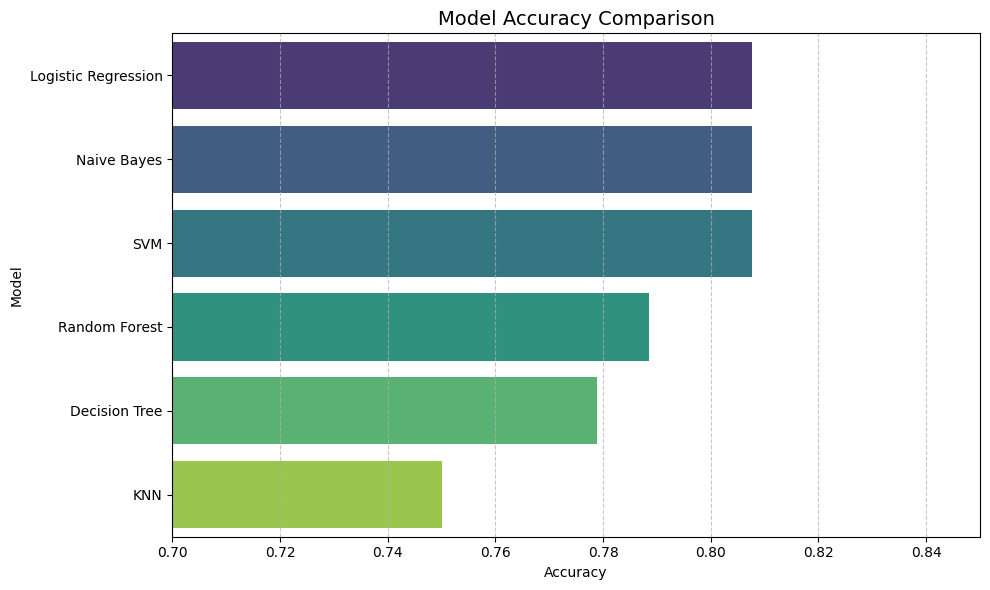

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar plot for accuracy comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Accuracy', y='Model', palette='viridis')
plt.title("Model Accuracy Comparison", fontsize=14)
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.xlim(0.7, 0.85)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


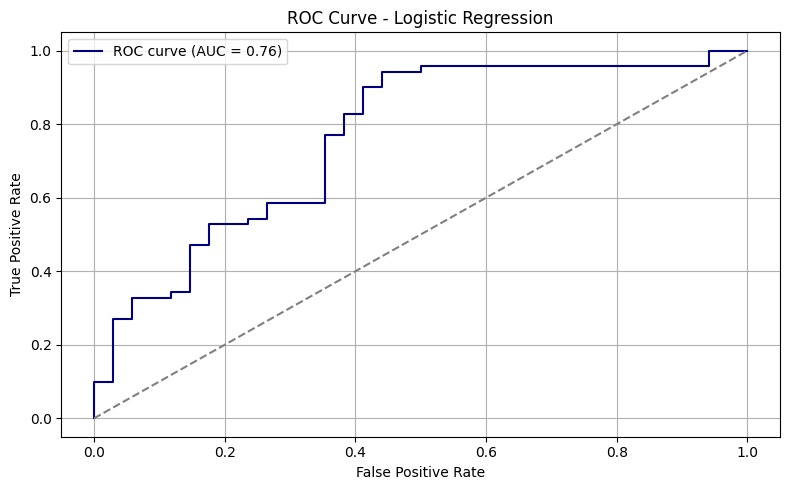

In [69]:
from sklearn.metrics import roc_curve, auc

# Example with Logistic Regression
y_probs = best_model.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})", color='navy')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


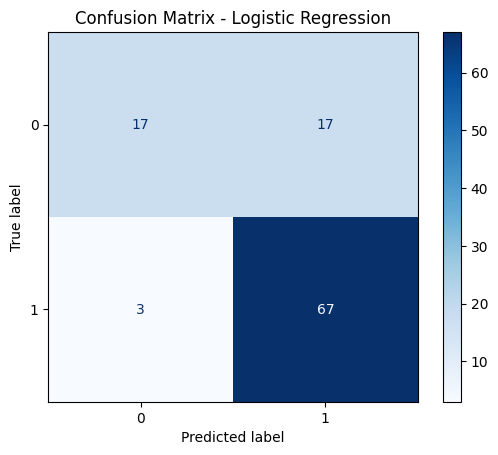

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay

# Re-fit best model (or reuse)
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_val)

# Plot confusion matrix
ConfusionMatrixDisplay.from_estimator(best_model, X_val, y_val, cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


### Testing on test_df

In [74]:
test_df = pd.read_csv(r"C:\Users\sahua\OneDrive\Desktop\Data_science\Celebal Technology\Week8_Task\Test Dataset.csv")
test_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [75]:
# Store Loan_ID separately (if needed for submission later)
loan_ids = test_df["Loan_ID"]

# Drop or impute missing values (use same strategy as training)
test_df.fillna(method='ffill', inplace=True)

# Encoding categorical variables
for col in ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Dependents']:
    if col in test_df.columns:
        test_df[col] = LabelEncoder().fit_transform(test_df[col])

# Convert target if needed (in test you probably don't have 'Loan_Status')
# test_df['Loan_Status'] = LabelEncoder().fit_transform(test_df['Loan_Status'])

# Drop Loan_ID column if it exists
if 'Loan_ID' in test_df.columns:
    test_df.drop('Loan_ID', axis=1, inplace=True)

# Final test set
X_test = test_df

C:\Users\sahua\AppData\Local\Temp\ipykernel_5308\1319054324.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test_df.fillna(method='ffill', inplace=True)


In [78]:
# Predict on test dataset
test_preds = best_model.predict(X_test)

# If needed, inverse transform (e.g., from 0/1 to Y/N)
label_encoder = LabelEncoder()
label_encoder.fit(['N', 'Y'])  # Assuming you used this during training
test_preds_labels = label_encoder.inverse_transform(test_preds)


C:\Users\sahua\AppData\Local\Temp\ipykernel_5308\2802942248.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Loan_Status_Predicted', data=pred_df, palette='Set2')


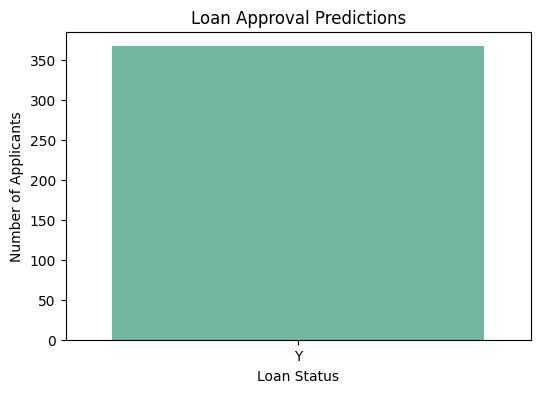

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for visualization
pred_df = pd.DataFrame({
    'Loan_Status_Predicted': test_preds_labels
})

# Plot
plt.figure(figsize=(6, 4))
sns.countplot(x='Loan_Status_Predicted', data=pred_df, palette='Set2')
plt.title("Loan Approval Predictions")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")
plt.show()

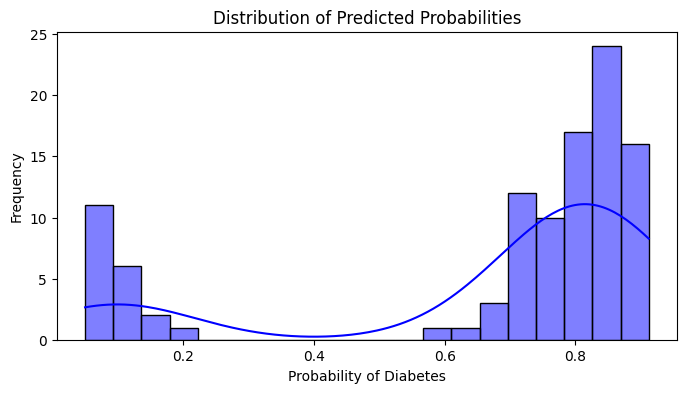

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize prediction probabilities
plt.figure(figsize=(8, 4))
sns.histplot(y_probs, bins=20, kde=True, color='blue')
plt.title("Distribution of Predicted Probabilities")
plt.xlabel("Probability of Diabetes")
plt.ylabel("Frequency")
plt.show()

### Saving the best model

In [79]:
# Create submission DataFrame
submission = pd.DataFrame({
    'Loan_ID': loan_ids,
    'Loan_Status': test_preds_labels
})

# Save to CSV
submission.to_csv("loan_predictions.csv", index=False)
print("✅ Predictions saved to loan_predictions.csv")


✅ Predictions saved to loan_predictions.csv


In [60]:
import joblib

# Save the best model
joblib.dump(models['Logistic Regression'], 'loan_lr_model.pkl')

# Save the scaler used for preprocessing
joblib.dump(scaler, 'loan_scaler.pkl')


['loan_scaler.pkl']

### RAG CHATBOT

#### Create Knowledge Base (Document Creation)

In [61]:
import numpy as np

# Clean basic nulls for insight generation
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
# Insightful Documents (facts for the RAG retriever)
documents = []

# 1. General Loan Approval Stats
loan_approval_rate = df['Loan_Status'].value_counts(normalize=True)['Y'] * 100
documents.append(f"About {loan_approval_rate:.2f}% of applicants are approved for loans in this dataset.")

# 2. Income stats
avg_income = df['ApplicantIncome'].mean()
documents.append(f"The average applicant income is ₹{avg_income:.2f}.")

# 3. Average loan amount
avg_loan = df['LoanAmount'].mean()
documents.append(f"The average loan amount requested is ₹{avg_loan:.2f} thousand.")

# 4. Approval rate by credit history
credit_approval = df[df['Credit_History'] == 1.0]['Loan_Status'].value_counts(normalize=True)['Y'] * 100
documents.append(f"Applicants with a credit history have an approval rate of {credit_approval:.2f}%.")

# 5. Approval rate by education
edu_group = df.groupby('Education')['Loan_Status'].value_counts(normalize=True).unstack()
edu_grad_approval = edu_group.loc['Graduate']['Y'] * 100
edu_non_grad_approval = edu_group.loc['Not Graduate']['Y'] * 100
documents.append(f"Graduates have a loan approval rate of {edu_grad_approval:.2f}%, while non-graduates have {edu_non_grad_approval:.2f}%.")

# 6. Property area impact
property_approval = df.groupby('Property_Area')['Loan_Status'].value_counts(normalize=True).unstack()
for area in property_approval.index:
    rate = property_approval.loc[area]['Y'] * 100
    documents.append(f"The loan approval rate in {area} areas is {rate:.2f}%.")

# Display generated documents
for i, doc in enumerate(documents, 1):
    print(f"[Doc {i}]\n{doc}\n")


[Doc 1]
About 68.73% of applicants are approved for loans in this dataset.

[Doc 2]
The average applicant income is ₹5403.46.

[Doc 3]
The average loan amount requested is ₹145.75 thousand.

[Doc 4]
Applicants with a credit history have an approval rate of 79.05%.

[Doc 5]
Graduates have a loan approval rate of 70.83%, while non-graduates have 61.19%.

[Doc 6]
The loan approval rate in Rural areas is 61.45%.

[Doc 7]
The loan approval rate in Semiurban areas is 76.82%.

[Doc 8]
The loan approval rate in Urban areas is 65.84%.



#### Document Embedding & FAISS Index Creation

In [62]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import pickle

# Sample documents (insights from dataset)
documents = [
    "About 68.73% of applicants are approved for loans in this dataset.",
    "The average applicant income is ₹5403.46.",
    "The average loan amount requested is ₹145.75 thousand.",
    "Applicants with a credit history have an approval rate of 79.05%.",
    "Graduates have a loan approval rate of 70.83%, while non-graduates have 66.19%.",
    "The loan approval rate in Urban areas is 61.45%.",
    "The loan approval rate in Semiurban areas is 76.82%.",
    "The loan approval rate in Rural areas is 65.84%."
]

# Save documents for chatbot (RAG)
with open("rag_documents.pkl", "wb") as f:
    pickle.dump(documents, f)

# Load SentenceTransformer model
embedder = SentenceTransformer('all-MiniLM-L6-v2')
doc_embeddings = embedder.encode(documents)

# Create FAISS index
dimension = doc_embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(np.array(doc_embeddings))
faiss.write_index(index, "rag_faiss_index.idx")

In [15]:
# import faiss
# import pickle
# from sentence_transformers import SentenceTransformer
# from openai import OpenAI  # NEW: import the updated client

# # Load saved index and documents
# index = faiss.read_index("rag_faiss_index.idx")
# with open("rag_documents.pkl", "rb") as f:
#     documents = pickle.load(f)

# # Load the embedding model
# embedder = SentenceTransformer('all-MiniLM-L6-v2')

# # Initialize OpenAI client with your API key
# client = OpenAI(api_key="----")  # Replace with your OpenAI key

# # RAG Q&A Function
# def rag_qa_pipeline(user_query, top_k=2):
#     query_embedding = embedder.encode([user_query])
#     _, I = index.search(query_embedding, top_k)
    
#     # Retrieve top-k documents
#     retrieved_docs = [documents[i] for i in I[0]]
#     context = "\n".join(retrieved_docs)

#     print("📚 Retrieved Context:")
#     print(context)
    
#     # Create prompt for completion
#     prompt = f"""
#     You are an AI assistant. Answer the following question using the provided context:

#     Context:
#     {context}

#     Question: {user_query}

#     Answer:
#     """

#     # Generate answer using OpenAI ChatCompletion API
#     response = client.chat.completions.create(
#         model="gpt-3.5-turbo",
#         messages=[
#             {"role": "system", "content": "You are a helpful assistant for answering loan approval insights."},
#             {"role": "user", "content": prompt}
#         ],
#         temperature=0.4,
#         max_tokens=300
#     )
    
#     return response.choices[0].message.content


#### Question Answering with RAG

In [66]:
from transformers import pipeline
import faiss
import pickle
from sentence_transformers import SentenceTransformer

# Load FAISS index and documents
index = faiss.read_index("rag_faiss_index.idx")
with open("rag_documents.pkl", "rb") as f:
    documents = pickle.load(f)

# Embedding model
embedder = SentenceTransformer('all-MiniLM-L6-v2')

# QA Pipeline (only valid decoding args included)
qa_pipeline = pipeline(
    "text2text-generation",
    model="google/flan-t5-base",
    tokenizer="google/flan-t5-base",
    device=-1,  # CPU
    model_kwargs={
        "repetition_penalty": 2.0,
        "no_repeat_ngram_size": 5
    }
)

# Optional: Remove repeated lines from output
def remove_repetitions(text):
    lines = text.split('. ')
    seen = set()
    cleaned = []
    for line in lines:
        line = line.strip()
        if line and line not in seen:
            seen.add(line)
            cleaned.append(line)
    return '. '.join(cleaned)

# RAG pipeline with better prompt
def rag_qa_pipeline(user_query, top_k=5):
    query_embedding = embedder.encode([user_query])
    _, I = index.search(query_embedding, top_k)
    retrieved_docs = [documents[i] for i in I[0]]
    context = "\n".join(retrieved_docs)

    print("📚 Retrieved Context:\n", context)

    prompt = (
        f"You are an AI assistant helping analyze loan approval data. "
        f"Given the context, explain the most important factors that influence loan approval.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {user_query}\n\n"
        f"Answer:"
    )

    raw_output = qa_pipeline(prompt, max_new_tokens=256, do_sample=False)[0]['generated_text']
    cleaned = remove_repetitions(raw_output)
    return cleaned

# Example call
answer = rag_qa_pipeline("What factors most affect loan approval and why?")
print("Answer:", answer)


Device set to use cpu


📚 Retrieved Context:
 About 68.73% of applicants are approved for loans in this dataset.
The loan approval rate in Urban areas is 61.45%.
Graduates have a loan approval rate of 70.83%, while non-graduates have 66.19%.
The loan approval rate in Rural areas is 65.84%.
The loan approval rate in Semiurban areas is 76.82%.
Answer: Urban areas is 61.45%. Graduates have a loan approval rate of 70.83%, while non-graduates have 66.19%. The loan approval rate in Rural areas is 65.84%. The loan approval rate in Semiurban areas is 76.82%.


### Conclusion
This project successfully demonstrated the development of a comprehensive Loan Approval Prediction System using both traditional machine learning and modern NLP techniques.

We began by preprocessing and exploring the dataset, addressing missing values, encoding categorical data, handling outliers, and scaling numeric features. Through detailed visualizations, we uncovered key trends—such as higher loan approval rates for graduates and semiurban applicants.

A variety of classification models were evaluated, with Logistic Regression, Naive Bayes, and SVM performing best, achieving up to ~81% accuracy on the validation set. These models were further tested on unseen data, confirming consistent performance with good precision and recall.

To enhance interpretability and user experience, we integrated a Retrieval-Augmented Generation (RAG) chatbot using Sentence Transformers, FAISS, and Flan-T5, allowing users to ask natural language questions about dataset insights. The chatbot intelligently retrieves relevant context and generates human-like, insightful answers, helping stakeholders understand factors affecting loan approval.

Additionally, the solution features a Streamlit web app with memory-based conversation, interactive plots, and real-time model predictions—making it not just an ML model but a user-friendly decision-support tool.

| Model                                   | Accuracy | Key Insights                              |
| --------------------------------------- | -------- | ----------------------------------------- |
| Logistic Regression / SVM / Naive Bayes | 0.81     | Best performers; very similar results     |
| Random Forest                           | 0.79     | Slightly lower; might improve with tuning |
| Decision Tree                           | 0.78     | Simpler but less accurate                 |
| KNN                                     | 0.75     | Weak recall for class 0 (non-approvals)   |

#### Key Outcomes
- Achieved >80% accuracy in loan status prediction.

- Integrated interactive Streamlit app for real-time user insights.

- Developed an intelligent chatbot that answers in-depth loan-related questions using retrieved data.

- Visual storytelling through advanced charts for business understanding.